In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.dropna(inplace=True)

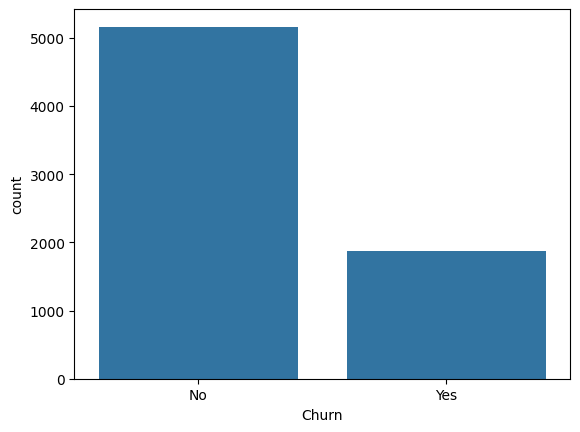

In [8]:
sns.countplot(x="Churn", data=df)
plt.show()

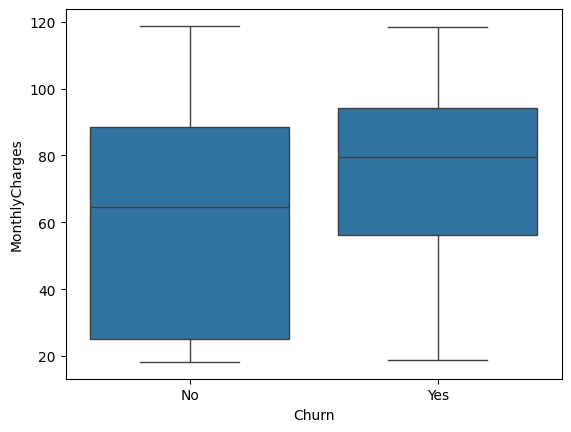

In [10]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)

plt.show()

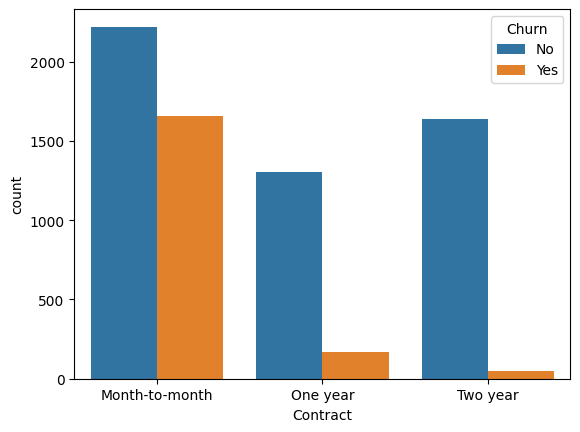

In [11]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

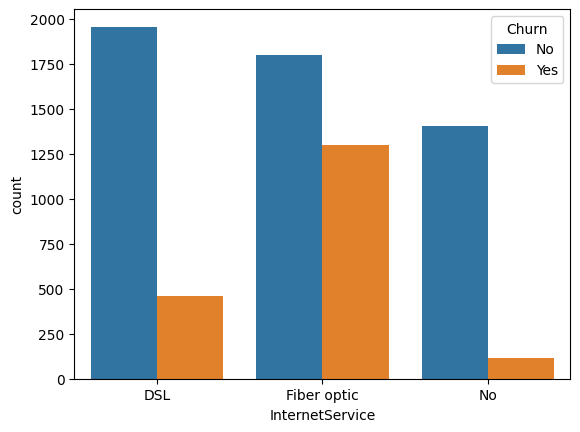

In [12]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

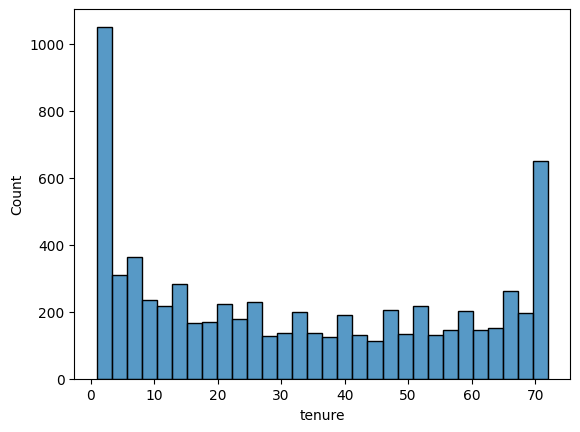

In [13]:
sns.histplot(df["tenure"], bins=30)
plt.show()

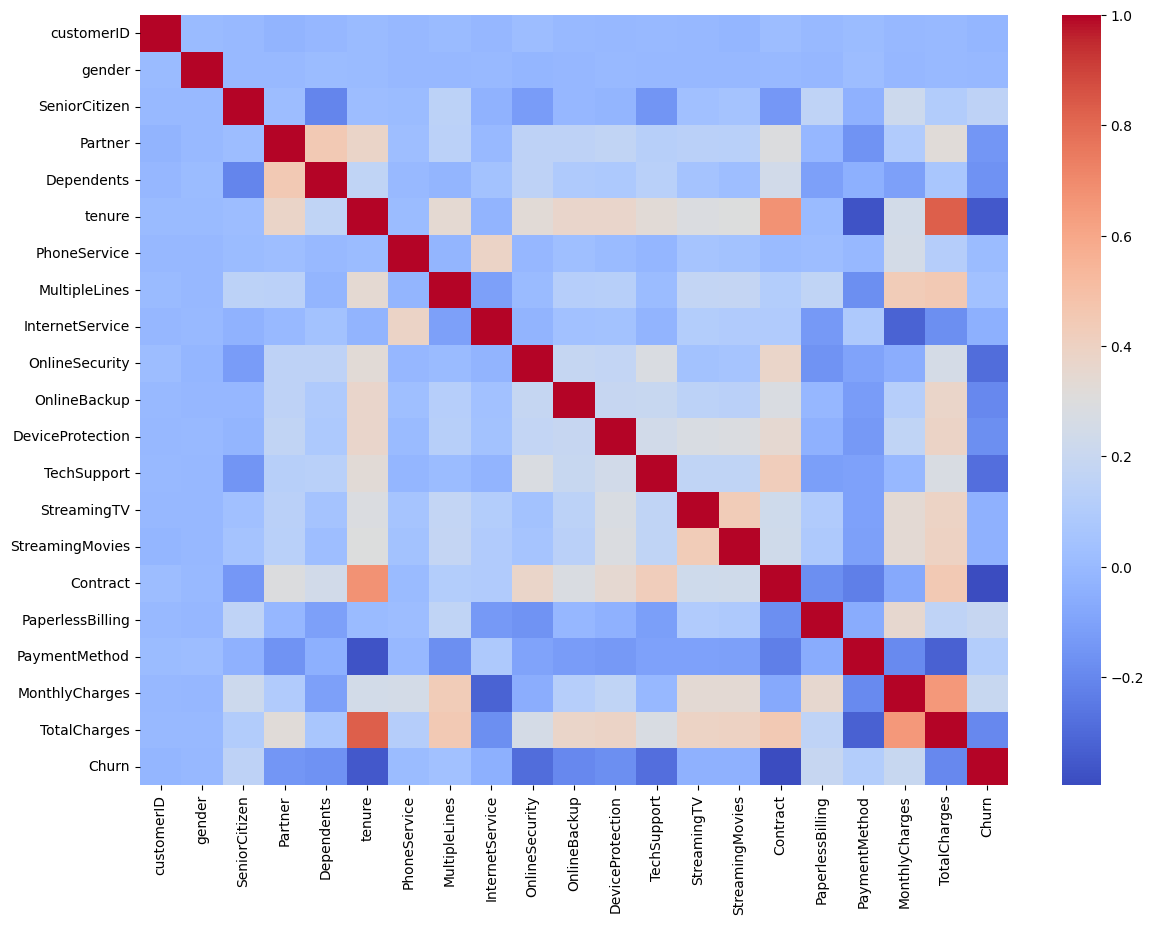

In [14]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(),
            cmap="coolwarm")

plt.show()

In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [19]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [20]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [21]:
print("LR Accuracy:",
      accuracy_score(y_test, pred_lr))

print("RF Accuracy:",
      accuracy_score(y_test, pred_rf))

print("XGB Accuracy:",
      accuracy_score(y_test, pred_xgb))

LR Accuracy: 0.7789623312011372
RF Accuracy: 0.7896233120113717
XGB Accuracy: 0.7683013503909026


In [22]:
from sklearn.metrics import recall_score

print(recall_score(y_test, pred_lr))
print(recall_score(y_test, pred_rf))
print(recall_score(y_test, pred_xgb))

0.2967914438502674
0.4358288770053476
0.47593582887700536


In [23]:
prob_lr = lr.predict_proba(X_test)[:,1]

prob_rf = rf.predict_proba(X_test)[:,1]

prob_xgb = xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, prob_lr))
print(roc_auc_score(y_test, prob_rf))
print(roc_auc_score(y_test, prob_xgb))

0.8260504941217884
0.8218612006978273
0.8078515926303638


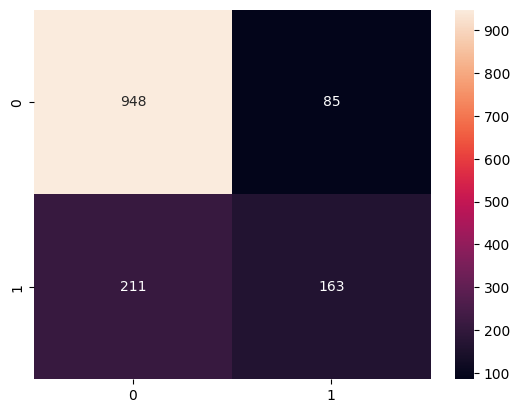

In [24]:
sns.heatmap(
    confusion_matrix(y_test, pred_rf),
    annot=True,
    fmt="d"
)

plt.show()

In [25]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

       False       0.82      0.92      0.86      1033
        True       0.66      0.44      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.69      1407
weighted avg       0.78      0.79      0.77      1407



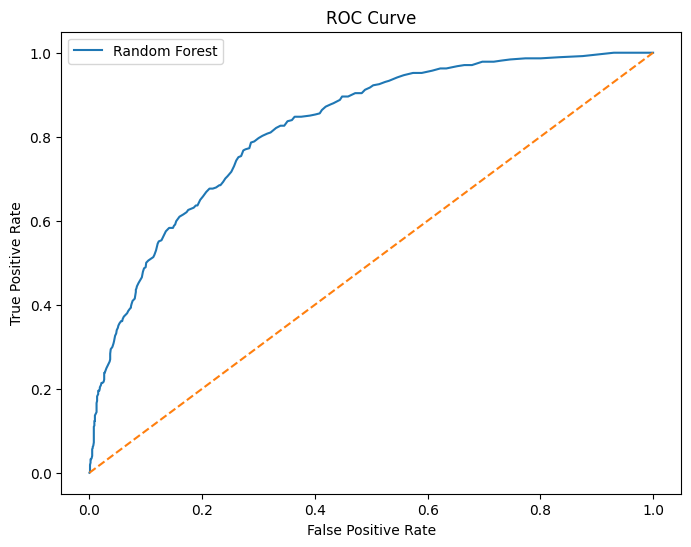

In [26]:
fpr, tpr, _ = roc_curve(y_test, prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

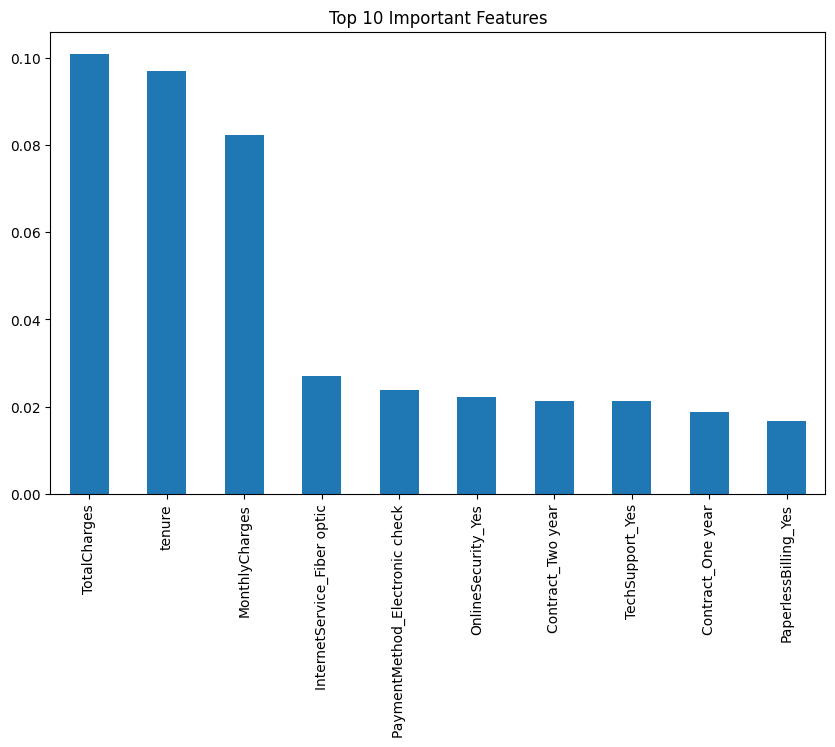

In [27]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()